In [1]:
import sys
import torch
import logging
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib import colormaps as cm

from f3 import init_event_model, load_weights_ckpt
from f3.utils import (setup_torch, ev_to_frames, plot_patched_features,
                      smooth_time_weighted_rgb_encoding, BaseExtractor)
from f3.tasks.depth.utils import init_depth_model, load_depth_weights, get_disparity_image
from f3.tasks.optical_flow.utils import init_flow_model, load_flow_weights, flow_viz_np
from f3.tasks.segmentation.utils import init_segmentation_model, load_segmentation_weights, cityscapes_palette

logging.basicConfig(stream=sys.stdout, level=logging.INFO, format="%(asctime)s - %(message)s")
logger = logging.getLogger(__name__)

setup_torch(cudnn_benchmark=False)

/home/jovyan/miniconda3/envs/f3/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torchsparse not installed. Sparse operations will not work.
torchsparse not installed. Sparse operations will not work.
Please install torchsparse, if you want to use SparsePatchFF.


### Download Pretrained Models and a Minimal M3ED Sequence

In [2]:
# Download pretrained F3 model weights
if False:
    !bash scripts/download/download_models.sh pretrained_models/f3 f3
    !bash scripts/download/download_models.sh pretrained_models/seg seg
    !bash scripts/download/download_models.sh pretrained_models/depth depth
    !bash scripts/download/download_models.sh pretrained_models/flow flow

    # Download a small M3ED sequence and generate the timestamps file
    !python3 scripts/download/download_m3ed.py --vehicle car\
                                               --environment urban\
                                               --sequence car_urban_day_penno_small_loop\
                                               --output_dir data\
                                               --to_download data
    !python3 scripts/generate_ts.py --data_h5 data/car_urban_day_penno_small_loop/car_urban_day_penno_small_loop_data.h5
    
    # For ONNX inference, later.
    !pip install onnx onnxruntime onnxscript onnxruntime-gpu

In [3]:
################ Path where Models are downloaded ################
BASE_F3_MODEL_PATH = "pretrained_models/f3/"
BASE_SEG_MODEL_PATH = "pretrained_models/seg/"
BASE_DEPTH_MODEL_PATH = "pretrained_models/depth/"
BASE_FLOW_MODEL_PATH = "pretrained_models/flow/"

################ Model Names to Load ################
F3_MODEL_NAME = "patchff_fullcardaym3ed_small_20ms.pth"
F3_CONFIG_NAME = "confs/ff/modeloptions/1280x720x20_patchff_ds1_small.yml"
SEG_MODEL_NAME = "segformer_b3_fullm3ed_800x600x20"
DEPTH_MODEL_NAME = "dav2b_fullm3ed_pseudo_518x518x20"
FLOW_MODEL_NAME = "optflow_trainm3ed_20msff_pyr5_28k"

################ Path to a M3ED Sequence ################
H5PATH = "data/car_urban_day_penno_small_loop/car_urban_day_penno_small_loop_data.h5"
TSPATH = "data/car_urban_day_penno_small_loop/50khz_car_urban_day_penno_small_loop_data.npy"

In [4]:
extractor = BaseExtractor(H5PATH, TSPATH, w=1280, h=720, time_ctx=20000,
                          time_pred=20000, bucket=1000, max_numevents_ctx=800000,
                          randomize_ctx=False, camera="left")

## Initializing and Loading Pretrained Models

### Loading a pretrained F<sup>3</sup>

In [5]:
eventff_model = init_event_model(F3_CONFIG_NAME, return_feat=True, return_logits=True).cuda()
eventff_model = torch.compile(
    eventff_model,
    fullgraph=False,
    backend="inductor",
    options={
        "epilogue_fusion": True,
        "max_autotune": True,
    },
)
epoch, loss, acc = load_weights_ckpt(eventff_model, Path(BASE_F3_MODEL_PATH) / F3_MODEL_NAME)
eventff_model.eval()
logger.info(f"Loaded F3 model ckpt from {F3_MODEL_NAME} at epoch {epoch} with loss {loss} and acc {acc}")

2025-11-07 01:26:49,846 - Instantiating Multi-resolution Hash Encoder with the following resolutions: tensor([[160.0000,  90.0000,  20.0000],
        [ 47.4074,  32.7273,  10.0000],
        [ 13.7634,  11.4286,   5.0000],
        [  4.0000,   4.0000,   2.5000]])
2025-11-07 01:26:49,847 - Using 3D Multi-Resolution Hash Encoder with 0 hashed levels and 4 non-hashed levels and polarity: False
2025-11-07 01:26:49,871 - Spatial receptive field: 37
2025-11-07 01:26:49,955 - Loaded F3 model ckpt from patchff_fullcardaym3ed_small_20ms.pth at epoch 199 with loss 0.008952121764442997 and acc 0.7459951043128967


### Loading ONNX-converted F<sup>3</sup>
This was converted using the [export script](./export_to_onnx.py).

In [15]:
import onnxruntime
f3_backbone_session = onnxruntime.InferenceSession("1280x720x20_patchff_ds1_small.onnx", providers=["CUDAExecutionProvider"])

2025-11-07 02:08:43.129778549 [W:onnxruntime:, transformer_memcpy.cc:111 ApplyImpl] 2 Memcpy nodes are added to the graph main_graph for CUDAExecutionProvider. It might have negative impact on performance (including unable to run CUDA graph). Set session_options.log_severity_level=1 to see the detail logs before this message.
2025-11-07 02:08:43.131100976 [W:onnxruntime:, session_state.cc:1316 VerifyEachNodeIsAssignedToAnEp] Some nodes were not assigned to the preferred execution providers which may or may not have an negative impact on performance. e.g. ORT explicitly assigns shape related ops to CPU to improve perf.
2025-11-07 02:08:43.131110816 [W:onnxruntime:, session_state.cc:1318 VerifyEachNodeIsAssignedToAnEp] Rerunning with verbose output on a non-minimal build will show node assignments.


### Loading a pretrained F<sup>3</sup> - SegFormer B3

In [7]:
seg_model = init_segmentation_model(Path(BASE_SEG_MODEL_PATH) / SEG_MODEL_NAME / "segmentation_config.yml").cuda()
seg_model.eventff = torch.compile(seg_model.eventff, fullgraph=False)
epoch, loss, acc, miou = load_segmentation_weights(seg_model, Path(BASE_SEG_MODEL_PATH) / SEG_MODEL_NAME / "best_miou.pth")
logger.info(f"Loaded Segmentation ckpt from {SEG_MODEL_NAME} at " +
            f"Epoch: {epoch}, Loss: {loss}, Acc: {acc}, MIoU: {miou}")
seg_model.eval()

2025-11-07 01:26:50,387 - Instantiating Multi-resolution Hash Encoder with the following resolutions: tensor([[160.0000,  90.0000,  20.0000],
        [ 47.4074,  32.7273,  10.0000],
        [ 13.7634,  11.4286,   5.0000],
        [  4.0000,   4.0000,   2.5000]])
2025-11-07 01:26:50,387 - Using 3D Multi-Resolution Hash Encoder with 0 hashed levels and 4 non-hashed levels and polarity: False
2025-11-07 01:26:50,409 - Spatial receptive field: 37
2025-11-07 01:26:52,970 - Loaded Segmentation ckpt from segformer_b3_fullm3ed_800x600x20 at Epoch: 109, Loss: 0.25034812944792173, Acc: 0.9427886767964132, MIoU: 0.706604860036202


EventFFSegformer(
  (segformer): SegformerForSemanticSegmentation(
    (segformer): SegformerModel(
      (encoder): SegformerEncoder(
        (patch_embeddings): ModuleList(
          (0): SegformerOverlapPatchEmbeddings(
            (proj): Conv2d(32, 64, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
            (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
          )
          (1): SegformerOverlapPatchEmbeddings(
            (proj): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
            (layer_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          )
          (2): SegformerOverlapPatchEmbeddings(
            (proj): Conv2d(128, 320, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
            (layer_norm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
          )
          (3): SegformerOverlapPatchEmbeddings(
            (proj): Conv2d(320, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
         

### Loading a pretrained F<sup>3</sup> - DepthAnything V2 Base

In [8]:
depth_model = init_depth_model(Path(BASE_DEPTH_MODEL_PATH) / DEPTH_MODEL_NAME / "depth_config.yml").cuda()
depth_model.eventff = torch.compile(depth_model.eventff, fullgraph=False)
epoch, results = load_depth_weights(depth_model, Path(BASE_DEPTH_MODEL_PATH) / DEPTH_MODEL_NAME / "best.pth")
logger.info(f"Loaded Monocular Depth ckpt from {DEPTH_MODEL_NAME} at " +
            f"Epoch: {epoch}, Results: {results}")
depth_model.eval()

2025-11-07 01:26:52,994 - Instantiating Multi-resolution Hash Encoder with the following resolutions: tensor([[160.0000,  90.0000,  20.0000],
        [ 47.4074,  32.7273,  10.0000],
        [ 13.7634,  11.4286,   5.0000],
        [  4.0000,   4.0000,   2.5000]])
2025-11-07 01:26:52,995 - Using 3D Multi-Resolution Hash Encoder with 0 hashed levels and 4 non-hashed levels and polarity: False
2025-11-07 01:26:53,025 - Spatial receptive field: 37
2025-11-07 01:26:53,040 - using MLP layer as FFN
2025-11-07 01:26:55,996 - Loaded Monocular Depth ckpt from dav2b_fullm3ed_pseudo_518x518x20 at Epoch: 99, Results: {'d1': 0.08743250370025635, 'd2': 0.08900193870067596, 'd3': 0.09213952720165253, 'abs_rel': 100, 'sq_rel': 100, 'rmse': 100, 'rmse_log': 1.9475206136703491, 'log10': 0.6172302961349487, 'silog': 1.695786714553833, 'ssimae': 0.16258996725082397}


EventFFDepthAnythingV2(
  (dav2): DepthAnythingV2(
    (pretrained): DinoVisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(32, 768, kernel_size=(14, 14), stride=(14, 14))
        (norm): Identity()
      )
      (blocks): ModuleList(
        (0-11): 12 x NestedTensorBlock(
          (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (attn): MemEffAttention(
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=768, out_features=768, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (ls1): LayerScale()
          (drop_path1): Identity()
          (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (act): GELU(approximate='none')
            (fc2): Linear(in_features=3072, out_

### Loading a pretrained F<sup>3</sup> - Flow Model

In [9]:
optflow_model = init_flow_model(Path(BASE_FLOW_MODEL_PATH) / FLOW_MODEL_NAME / "flow_config.yaml").cuda()
optflow_model.eventff = torch.compile(optflow_model.eventff, fullgraph=False)
optflow_model.flowhead = torch.compile(optflow_model.flowhead, fullgraph=False)
epoch, loss = load_flow_weights(optflow_model, Path(BASE_FLOW_MODEL_PATH) / FLOW_MODEL_NAME / "last.pth")
logger.info(f"Loaded Optical Flow ckpt from {FLOW_MODEL_NAME} at " +
            f"Epoch: {epoch}, Loss: {loss}")
optflow_model.eval()

2025-11-07 01:26:56,015 - Instantiating Multi-resolution Hash Encoder with the following resolutions: tensor([[160.0000,  90.0000,  20.0000],
        [ 47.4074,  32.7273,  10.0000],
        [ 13.7634,  11.4286,   5.0000],
        [  4.0000,   4.0000,   2.5000]])
2025-11-07 01:26:56,016 - Using 3D Multi-Resolution Hash Encoder with 0 hashed levels and 4 non-hashed levels and polarity: False
2025-11-07 01:26:56,033 - Spatial receptive field: 37
2025-11-07 01:26:56,148 - Loaded Optical Flow ckpt from optflow_trainm3ed_20msff_pyr5_28k at Epoch: 99, Loss: 0.0030333592851073945


EventFFFlow(
  (eventff): OptimizedModule(
    (_orig_mod): EventPatchFF(
      (multi_hash_encoder): MultiResolutionHashEncoder()
      (downsample_layers): ModuleList(
        (0): Sequential(
          (0): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (1): LayerNorm()
        )
        (1): Sequential(
          (0): LayerNorm()
          (1): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
        )
      )
      (stages): ModuleList(
        (0-1): 2 x Sequential(
          (0): Block(
            (dwconv): Conv2d(32, 32, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=32)
            (norm): LayerNorm()
            (pwconv1): Linear(in_features=32, out_features=64, bias=True)
            (act): GELU(approximate='none')
            (grn): GRN()
            (pwconv2): Linear(in_features=64, out_features=32, bias=True)
            (drop_path): Identity()
          )
          (1): Block(
            (dwconv): Conv2d(32, 32, kernel_size=(7, 7), stride=(1, 1)

### Run all models for inference

In [10]:
IMG_IDX = 700

t0 = extractor.hdf5_file["ovc/ts"][IMG_IDX]
img = extractor.hdf5_file["ovc/rgb/data"][IMG_IDX]

# get events in fixed time window
ctx, totcnt = extractor.get_ctx_fixedtime(t0)    
ctx, totcnt = ctx.cuda(), torch.tensor([totcnt]).cuda()

# make event frame for visualization
events_frame = ev_to_frames(ctx, totcnt, 1280, 720)[0].cpu().numpy().T

cmap = cm.get_cmap("magma")

# Run all models
with torch.no_grad():
    # F3 forward pass
    logits, feat = eventff_model(ctx, totcnt)
    
    # Segmentation forward pass
    seg_pred, _ = seg_model(ctx, totcnt)
    seg_pred = seg_pred.argmax(1).cpu().numpy()

    # Depth forward pass
    depth_pred, _ = depth_model.infer_image(ctx, totcnt)

    # Optical Flow forward pass
    flow_pred, _ = optflow_model(ctx, totcnt)
    flow_pred = flow_pred.permute(0, 2, 3, 1).cpu().numpy()

pca, _ = plot_patched_features(feat[0], plot=False)
logits_rgb = smooth_time_weighted_rgb_encoding((torch.sigmoid(logits) > 0.5).cpu().numpy())[0]
seg_img = cityscapes_palette(seg_model.num_labels)[seg_pred[0]].astype(np.uint8)
depth_img = get_disparity_image(depth_pred, torch.ones_like(depth_pred, dtype=torch.bool), cmap)
flow_img = flow_viz_np(flow_pred[0], norm=True) * (events_frame == 255)[..., None]

In [16]:
# Run ONNX inference
out = f3_backbone_session.run(None, {"currentBlock": ctx.cpu().numpy(), "eventCounts": totcnt.cpu().numpy()})

Help on method run in module onnxruntime.capi.onnxruntime_inference_collection:

run(output_names, input_feed, run_options=None) -> 'Sequence[np.ndarray | SparseTensor | list | dict]' method of onnxruntime.capi.onnxruntime_inference_collection.InferenceSession instance
    Compute the predictions.
    
    :param output_names: name of the outputs
    :param input_feed: dictionary ``{ input_name: input_value }``
    :param run_options: See :class:`onnxruntime.RunOptions`.
    :return: list of results, every result is either a numpy array,
        a sparse tensor, a list or a dictionary.
    
    ::
    
        sess.run([output_name], {input_name: x})



2025-11-07 02:08:45.885639830 [E:onnxruntime:, sequential_executor.cc:572 ExecuteKernel] Non-zero status code returned while running Expand node. Name:'node_expand' Status Message: /onnxruntime_src/onnxruntime/core/framework/bfc_arena.cc:359 void* onnxruntime::BFCArena::AllocateRawInternal(size_t, bool, onnxruntime::Stream*) Failed to allocate memory for requested buffer of size 5517590134784



RuntimeException: [ONNXRuntimeError] : 6 : RUNTIME_EXCEPTION : Non-zero status code returned while running Expand node. Name:'node_expand' Status Message: /onnxruntime_src/onnxruntime/core/framework/bfc_arena.cc:359 void* onnxruntime::BFCArena::AllocateRawInternal(size_t, bool, onnxruntime::Stream*) Failed to allocate memory for requested buffer of size 5517590134784


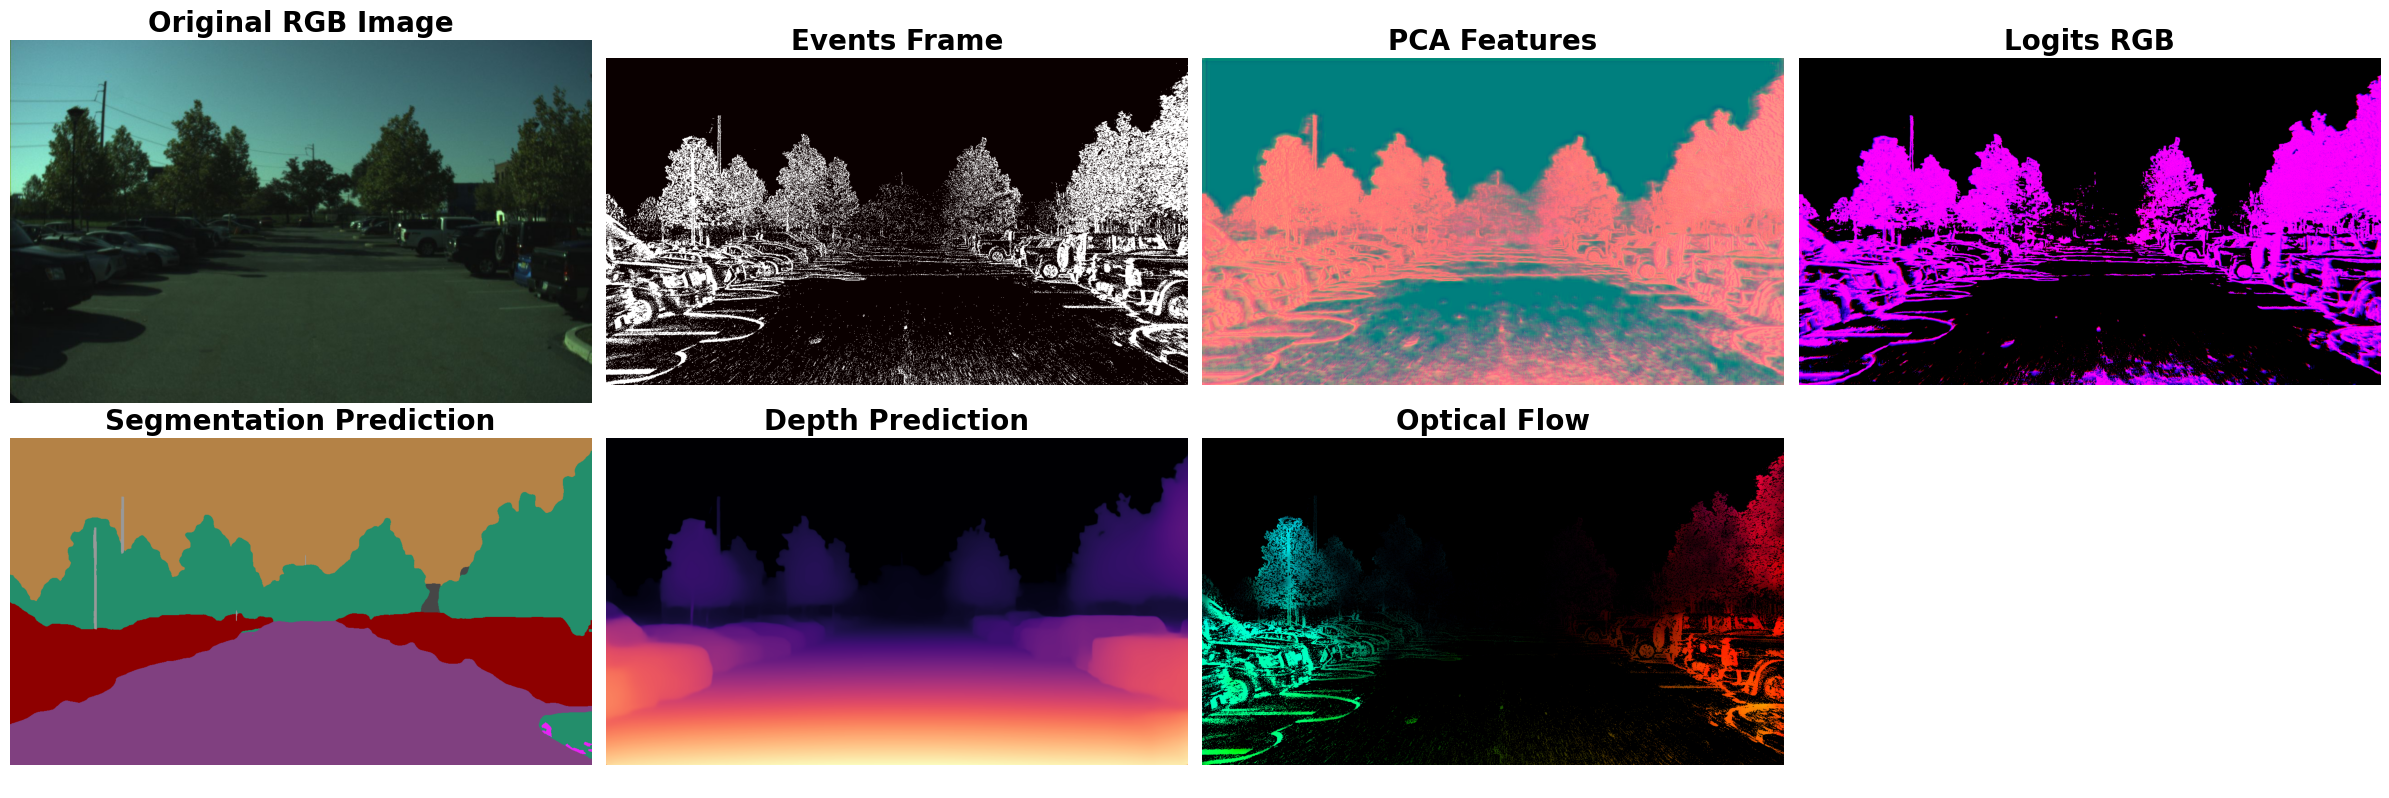

In [11]:
# Add optical flow to the visualization
fig, axes = plt.subplots(2, 4, figsize=(24, 8))

# Original RGB image
axes[0, 0].imshow(img[..., ::-1])
axes[0, 0].set_title('Original RGB Image', fontsize=20, fontweight='bold')
axes[0, 0].axis('off')

# Events frame
axes[0, 1].imshow(events_frame, cmap='hot')
axes[0, 1].set_title('Events Frame', fontsize=20, fontweight='bold')
axes[0, 1].axis('off')

# PCA features
axes[0, 2].imshow(pca.transpose(1, 0, 2))
axes[0, 2].set_title('PCA Features', fontsize=20, fontweight='bold')
axes[0, 2].axis('off')

# Logits RGB
axes[0, 3].imshow(logits_rgb.transpose(1, 0, 2))
axes[0, 3].set_title('Logits RGB', fontsize=20, fontweight='bold')
axes[0, 3].axis('off')

# Segmentation prediction
axes[1, 0].imshow(seg_img[..., ::-1])
axes[1, 0].set_title('Segmentation Prediction', fontsize=20, fontweight='bold')
axes[1, 0].axis('off')

# Depth image
axes[1, 1].imshow(depth_img)
axes[1, 1].set_title('Depth Prediction', fontsize=20, fontweight='bold')
axes[1, 1].axis('off')

# Optical flow
axes[1, 2].imshow(flow_img[..., ::-1])
axes[1, 2].set_title('Optical Flow', fontsize=20, fontweight='bold')
axes[1, 2].axis('off')

# Remove empty subplot
axes[1, 3].axis('off')

plt.tight_layout()
plt.show()